# Graph-based individual tree segmentation on a hand-labelled avocado point cloud (arXiv:2009.13727v2)

**Paper:** F. Westling, L. G. Underwood, M. Heuvelmans, Z. Zabawa, D. W. James, J. Underwood, *Graph-based methods for analyzing orchard tree structure using noisy point cloud data*, arXiv:2009.13727v2 (revised 2021-02-02). https://arxiv.org/abs/2009.13727

**Author code:** [fwestling/GraphTreeLS](https://github.com/fwestling/GraphTreeLS) (pinned commit `dc9ca8c7f6518bd90f41df411335014504b5ca17`) — Bash scripts over the ACFR **comma/snark** C++ libraries.

**Data:** Westling, *Avocado tree point clouds with class labels*, Mendeley Data, V1, DOI `10.17632/h49fpprg6c.1`, licence CC BY 4.0.

## What this notebook does (exact scope)

It reproduces **one minimal example** of the paper's core **graph operation** (§II-B) applied to **individual tree segmentation** (§II-D): a single three-tree avocado stand point cloud is de-grounded, voxelised into a graph (0.1 m voxels, 0.15 m edge radius), and every graph node is assigned to the trunk whose *shortest connected path* is shortest. Results are scored with the **v-measure** (§III-B) against the manual tree-identity labels and compared with the paper's *closest-trunk* straight-line baseline; unreached points are handled both ways the paper describes (discarded, or augmented by closest trunk — Fig. 14 caption).

> **AI-assisted translation notice / AI翻訳に関する注意**
> **This notebook is an AI-assisted Python translation of the paper's method (Sections II-B and II-D). The authors did not provide this Colab implementation; the original is a set of Bash scripts over ACFR comma/snark.** The author `install.sh` requires Ubuntu 18.04-era libraries (Qt4, ACFR qt3d) that are not installable on the current Colab Ubuntu 22.04 image, and the README states the scripts are "not isolation tested". The executed example and the checks below were validated, but untested behaviour is not guaranteed.
> **（本ノートブックは論文の手法を AI が Python へ翻訳したものです。原作者の Colab 実装は存在しません。原著は ACFR comma/snark を用いる Bash スクリプト群で、Ubuntu 18.04 時代のライブラリ（Qt4 等）を必要とするため、現在の Colab 環境では構築できません。検証済みの実行例以外の動作は保証されません。）**

**Known data quirk:** the Mendeley record page describes `matter_label` as 0=leaf / 1=trunk, but the files also contain `matter_label == 2`, which — together with `tree_label == 4` — is the ground plane (verified below against the record's `height` field and point extents). The observed label usage is printed from the bytes themselves.

**Not reproduced here (out of scope):** automated trunk detection (§II-C), matter classification (§II-E), the virtual SimTreeLS experiments, dataset-scale benchmarks and the enrichment ablation. A single-example v-measure is a plausibility check against the paper's dataset-level averages (§III-B: real-data average v-measure 0.915), **not** a verification of published accuracy.

## Runtime selection / ランタイム選択

**Select the `CPU` runtime (Runtime → Change runtime type → CPU). No GPU is required or used** — the method is pure graph search (voxelisation, k-d tree neighbours, Dijkstra shortest paths); there is no trained model and no weights. **ランタイムは CPU を選択してください。GPU は不要です（学習済みモデルを使わないグラフ探索のみのため）。**

- Expected wall time: a few minutes total, dominated by the ~52 MB download.
- Downloads: one 52 MB point-cloud file from Mendeley (public, no credentials).
- Run all: Runtime → Run all. Nothing prompts and no restart is needed.

### Setup: imports and method parameters

The scientific stack (numpy, scipy, scikit-learn, matplotlib, pandas) is preinstalled on Colab CPU runtimes. The parameters below are the paper's own: ground-removal search radius $R_g=1$ m, voxel size $v_s=0.1$ m, edge radius $R_e=0.15$ m (§II-B). Two choices are documented adaptations, not paper values: a 0.2 m tolerance for the ground local-minimum test, and a 1 m band for trunk-seed selection (§II-D requires one trunk point per tree at the tree–ground interface; the paper's real-data experiments used known trunk locations, and here seeds are derived from the dataset's own manual trunk labels).

使用するパラメータは論文独自の値（$R_g=1$ m, $v_s=0.1$ m, $R_e=0.15$ m）です。地面判定の許容差 0.2 m と幹シード選択の 1 m バンドは、文書化した実装上の選択です。

In [ ]:
import os, hashlib, urllib.request
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra
from scipy import ndimage
import matplotlib.pyplot as plt
from sklearn.metrics import v_measure_score

PARAMS = {
    "ground_radius_m": 1.0,   # R_g, paper Sec. II-B
    "ground_tol_m": 0.2,      # local-minimum tolerance (documented adaptation)
    "voxel_size_m": 0.1,      # v_s, paper Sec. II-B
    "edge_radius_m": 0.15,    # R_e, paper Sec. II-B
    "trunk_band_m": 1.0,      # trunk seed band above tree base (documented adaptation)
}
PARAMS

{'ground_radius_m': 1.0,
 'ground_tol_m': 0.2,
 'voxel_size_m': 0.1,
 'edge_radius_m': 0.15,
 'trunk_band_m': 1.0}

### Download the minimal sample from Mendeley (inside Colab)

One cloud, `r49-t65e.bin` (the smallest of the 40 clouds, 52,349,200 bytes = 1,308,730 points), is fetched from the dataset's public file endpoint and verified against the SHA-256 recorded in the Mendeley API file metadata (`content_details.sha256_hash`, file id `7324bf19-1a81-4c66-8781-3172438b3edf`). No credentials are used. **最小サンプル `r49-t65e.bin`（52 MB）を Mendeley の公開エンドポイントから取得し、API が公開している SHA-256 と照合します。認証情報は不要です。**

In [ ]:
DATA_URL = ("https://data.mendeley.com/public-files/datasets/h49fpprg6c/"
            "files/7324bf19-1a81-4c66-8781-3172438b3edf/file_downloaded")
EXPECTED_SHA256 = "cab0dad27de54952d9d606812aae6b01ad5bd27850e15ed5288e05e164e18039"
EXPECTED_BYTES = 52_349_200
local_path = "/content/r49-t65e.bin"

if not (os.path.exists(local_path) and os.path.getsize(local_path) == EXPECTED_BYTES):
    req = urllib.request.Request(DATA_URL, headers={"User-Agent": "phenopaper-colab-repro/1.0"})
    with urllib.request.urlopen(req, timeout=300) as resp, open(local_path, "wb") as f:
        total = 0
        while True:
            chunk = resp.read(1 << 20)
            if not chunk:
                break
            f.write(chunk)
            total += len(chunk)
            if total % (16 << 20) < (1 << 20):
                print(f"downloaded {total/1e6:.0f} MB", flush=True)
    print(f"finished: {total} bytes")
else:
    print("using cached download")

assert os.path.getsize(local_path) == EXPECTED_BYTES, "unexpected file size"
digest = hashlib.sha256(open(local_path, "rb").read()).hexdigest()
assert digest == EXPECTED_SHA256, f"sha256 mismatch: {digest}"
print("sha256 OK:", EXPECTED_SHA256)

downloaded 17 MB


downloaded 34 MB


downloaded 50 MB


finished: 52349200 bytes


sha256 OK: cab0dad27de54952d9d606812aae6b01ad5bd27850e15ed5288e05e164e18039


### Parse the comma/snark binary point cloud and verify the label layout

The dataset record documents the binary layout as `3d,2ui,d` — per point: `x,y,z` (8-byte doubles), two uint32 labels, and a final double `height` — with XYZ in **North-East-Down** orientation. We parse with this 40-byte dtype and validate the endianness from the label ranges (the `tree_label` field must be small integers). The observed cross-tabulation of the two label fields is printed from the bytes: as noted in the header, `matter_label == 2` and `tree_label == 4` correspond to the ground plane, while the three trees carry `tree_label` 1/2/3. **レコードレイアウト `3d,2ui,d`（40 バイト/点）でパースし、ラベル範囲からエンディアンを検証します。実際のバイト列から見たラベル対応（地面 = matter 2 / tree 4）をクロス集計で表示します。**

In [ ]:
point_dtype_le = np.dtype([("x", "<f8"), ("y", "<f8"), ("z", "<f8"),
                           ("matter", "<u4"), ("tree", "<u4"), ("height", "<f8")])
assert point_dtype_le.itemsize == 40
n_bytes = os.path.getsize(local_path)
assert n_bytes % point_dtype_le.itemsize == 0
n_records = n_bytes // point_dtype_le.itemsize

raw = open(local_path, "rb").read()
pts = np.frombuffer(raw, dtype=point_dtype_le, count=n_records)
if set(np.unique(pts["tree"]).tolist()) <= {0, 1, 2, 3, 4}:
    point_dtype = point_dtype_le
else:
    point_dtype = point_dtype_le.newbyteorder(">")
    pts = np.frombuffer(raw, dtype=point_dtype, count=n_records)
print("dtype:", point_dtype.str, "| points:", n_records)

x, y, z = pts["x"], pts["y"], pts["z"]
h_up = -z                      # height up (NED z is down)
matter, tree = pts["matter"].astype(int), pts["tree"].astype(int)

print("observed tree_label x matter_label cross-tab [rows=tree 0..4, cols=matter 0..2]:")
for t in range(5):
    print(f"  tree {t}: {[int(((tree == t) & (matter == m)).sum()) for m in range(3)]}")
print(f"height field range: {pts['height'].min():.2f} .. {pts['height'].max():.2f} m "
      f"(median {np.median(pts['height']):.2f} m; height above ground per the record)")
print("x range [m]:", x.min(), x.max())
print("y range [m]:", y.min(), y.max())

dtype: |V40 | points: 1308730
observed tree_label x matter_label cross-tab [rows=tree 0..4, cols=matter 0..2]:
  tree 0: [4328, 15, 0]
  tree 1: [241306, 54408, 0]
  tree 2: [133733, 38645, 0]
  tree 3: [123048, 34038, 0]
  tree 4: [0, 135, 679074]
height field range: 0.00 .. 4.79 m (median 0.19 m; height above ground per the record)
x range [m]: 7219304.795199871 7219310.966905594
y range [m]: 435575.9930267334 435589.83989715576


### Input preview with the manual annotations

Before any analysis we view the actual sample: a subsampled 3-D scatter coloured by the **manual tree-identity label** (left) and by the **manual matter label** (right), exactly as stored in the file. This is the raw input plus its reference annotations, not a prediction. **解析前に、ファイルに格納された木ごとのラベル（左）と葉/幹ラベル（右）を 3D 散布図で表示します。これは予測ではなく生入力と正解アノテーションです。**

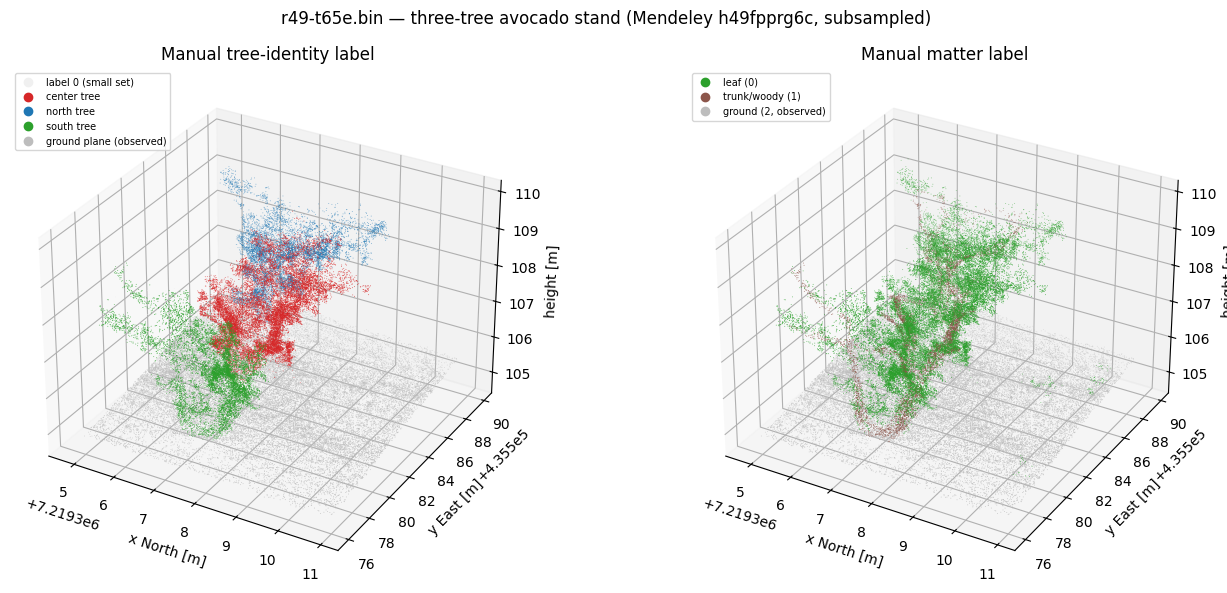

In [ ]:
rng = np.random.default_rng(0)
idx = rng.choice(n_records, size=min(80_000, n_records), replace=False)

TREE_COLORS = {0: "#f0f0f0", 1: "#d62728", 2: "#1f77b4", 3: "#2ca02c", 4: "#bdbdbd"}
TREE_NAMES = {0: "label 0 (small set)", 1: "center tree", 2: "north tree",
              3: "south tree", 4: "ground plane (observed)"}
MAT_COLORS = {0: "#2ca02c", 1: "#8c564b", 2: "#bdbdbd"}
MAT_NAMES = {0: "leaf (0)", 1: "trunk/woody (1)", 2: "ground (2, observed)"}

fig = plt.figure(figsize=(14, 6))
for k, (labels, cmap, names, title) in enumerate([
        (tree, TREE_COLORS, TREE_NAMES, "Manual tree-identity label"),
        (matter, MAT_COLORS, MAT_NAMES, "Manual matter label")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    order = np.argsort(labels[idx])
    ax.scatter(x[idx][order], y[idx][order], h_up[idx][order],
               c=[cmap[int(l)] for l in labels[idx][order]], s=0.4, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel("x North [m]"); ax.set_ylabel("y East [m]"); ax.set_zlabel("height [m]")
    handles = [plt.Line2D([], [], marker="o", ls="", color=cmap[k2], label=names[k2])
               for k2 in sorted(cmap)]
    ax.legend(handles=handles, loc="upper left", fontsize=7)
fig.suptitle("r49-t65e.bin — three-tree avocado stand (Mendeley h49fpprg6c, subsampled)")
plt.tight_layout()
plt.show()

### Ground removal by local height minima (paper §II-B)

The paper removes ground "by finding the local minima for each point in the Z axis within a lateral search radius $R_g=1$ m" before graph construction. AI-translation note: the author's exact `points-ground` script is not readable here, so this is a documented equivalent — heights are gridded into 0.5 m lateral cells, a 5×5-cell (≥ $R_g$) minimum filter gives each cell's local ground level, and points within 0.2 m of it are ground. As an independent cross-check (evaluation only, not an input) we compare against the ground plane identified in the labels (`tree_label == 4`) and correlate the record's `height` field with the local ground level. **論文 §II-B の局所最小値による地面除去を、0.5 m 格子＋5×5 最小値フィルタで実装します（AI 翻訳の注記：原著スクリプトは未公開のため等価実装）。ラベルから確認できる地面（tree 4）との一致率と、`height` フィールドとの整合を参考表示します。**

points: 1308730 | ground removed: 642830 (49.1%) | observed ground-plane points: 679209 (51.9%)
agreement with observed ground plane: 97.22%
corr(record height field, h_up - local ground level) = 0.9999


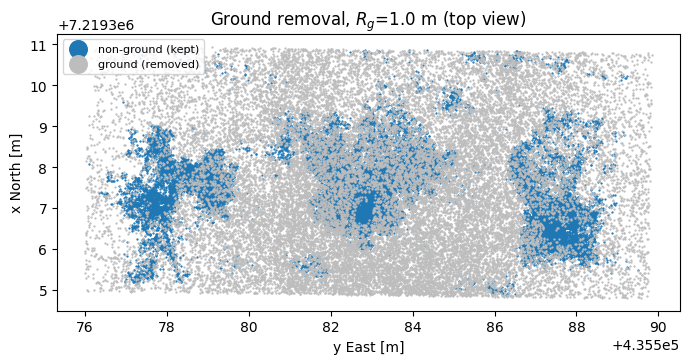

In [ ]:
cell = 0.5  # lateral grid cell [m]; 5x5 cells of 0.5 m spans +/-1.25 m >= R_g
ox, oy = x.min(), y.min()
gx = np.floor((x - ox) / cell).astype(np.int64)
gy = np.floor((y - oy) / cell).astype(np.int64)
grid = np.full((gx.max() + 1, gy.max() + 1), np.inf)
np.minimum.at(grid, (gx, gy), h_up)
local_min = ndimage.minimum_filter(grid, size=5, mode="constant", cval=np.inf)
local_min = np.where(np.isinf(local_min), np.nan, local_min)
ground_level = local_min[gx, gy]
is_ground = h_up <= ground_level + PARAMS["ground_tol_m"]

obs_ground = tree == 4
print(f"points: {n_records} | ground removed: {is_ground.sum()} "
      f"({100*is_ground.mean():.1f}%) | observed ground-plane points: {obs_ground.sum()} "
      f"({100*obs_ground.mean():.1f}%)")
print(f"agreement with observed ground plane: {100*(is_ground == obs_ground).mean():.2f}%")
corr = np.corrcoef(pts["height"], h_up - np.nan_to_num(ground_level))[0, 1]
print(f"corr(record height field, h_up - local ground level) = {corr:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
s = rng.choice(n_records, size=60_000, replace=False)
ax.scatter(y[s][~is_ground[s]], x[s][~is_ground[s]], s=0.4, c="#1f77b4", label="non-ground (kept)")
ax.scatter(y[s][is_ground[s]], x[s][is_ground[s]], s=0.4, c="#bdbdbd", label="ground (removed)")
ax.set_xlabel("y East [m]"); ax.set_ylabel("x North [m]")
ax.set_title(f"Ground removal, $R_g$={PARAMS['ground_radius_m']} m (top view)")
ax.legend(markerscale=20, fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Trunk seeds — one point per tree at the tree–ground interface (paper §II-D)

The graph operation needs one trunk node per tree as the path source (§II-D). The paper's automated trunk detection (§II-C) is out of scope; consistent with the paper's real-data setting where trunk locations were known, each seed is derived from the dataset's own manual labels: the centroid of a tree's **woody** (`matter_label == 1`) points within 1 m of that tree's base (a documented adaptation). The three seeds are printed and later used as shortest-path sources. **各木の「幹ラベル付き点」のうち基部から 1 m 以内の点の重心を幹シードとします（文書化した適応）。自動幹検出 §II-C は対象外です。**

In [ ]:
trunk_seeds = {}   # tree label -> seed (x North, y East, height up)
for t in (1, 2, 3):
    m_tree = tree == t
    base_h = h_up[m_tree].min()
    cand = m_tree & (matter == 1) & (h_up <= base_h + PARAMS["trunk_band_m"])
    seed = np.array([x[cand].mean(), y[cand].mean(), h_up[cand].mean()])
    trunk_seeds[t] = seed
    print(f"tree {t} ({TREE_NAMES[t]}): {int(cand.sum())} woody base points -> seed "
          f"[N {seed[0]:.2f}, E {seed[1]:.2f}, h {seed[2]:.2f}] m")

tree 1 (center tree): 11938 woody base points -> seed [N 7219307.17, E 435582.87, h 105.93] m
tree 2 (north tree): 10610 woody base points -> seed [N 7219306.33, E 435587.55, h 106.15] m
tree 3 (south tree): 13046 woody base points -> seed [N 7219307.57, E 435578.16, h 105.71] m


### Build the graph: 0.1 m voxels, 0.15 m neighbour edges (paper §II-B)

Non-ground points are voxelised at $v_s=0.1$ m; each node is the **average position of the points in its voxel** (§II-B). Nodes are connected to all neighbours within $R_e=0.15$ m — the paper's "simplest form", unweighted (the enrichment study of §II-B1/§IV-B showed no significant gain). Node/edge counts and timings are printed. **非地面点を 0.1 m ボクセル化し（節点＝ボクセル内平均位置）、0.15 m 以内の節点同士を無重みの辺で接続します（§II-B の最も単純な形）。**

In [ ]:
import time
t0 = time.time()
ng = ~is_ground
offs = np.array([x[ng].min(), y[ng].min(), h_up[ng].min()])
vs = PARAMS["voxel_size_m"]
vox_keys = np.floor((np.stack([x[ng], y[ng], h_up[ng]], 1) - offs) / vs).astype(np.int64)
vox_uniq, inverse, counts_ = np.unique(vox_keys, axis=0, return_inverse=True, return_counts=True)
n_nodes = len(vox_uniq)
node_xyz = np.stack([np.bincount(inverse, weights=x[ng]) / counts_,
                     np.bincount(inverse, weights=y[ng]) / counts_,
                     np.bincount(inverse, weights=h_up[ng]) / counts_], 1)
print(f"{n_nodes} voxel nodes from {int(ng.sum())} non-ground points ({time.time()-t0:.1f} s)")

t0 = time.time()
pairs = cKDTree(node_xyz).query_pairs(PARAMS["edge_radius_m"], output_type="ndarray")
graph = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])),
                   shape=(n_nodes, n_nodes)).tocsr()
graph = graph.maximum(graph.T).tocsr()
print(f"{len(pairs)} undirected edge pairs ({time.time()-t0:.1f} s)")

33584 voxel nodes from 665900 non-ground points (1.4 s)
190838 undirected edge pairs (0.1 s)


### Segmentation: shortest connected path to each trunk (paper §II-D)

For every graph node we compute shortest-path distances from the three trunk nodes (Dijkstra — exact shortest-path lengths, equivalent to the paper's A* with a zero heuristic; §II-B) and assign each reached node to the trunk with the **shortest path** ("closest through connected matter", §II-D). Unreached nodes are marked unassigned for now — the paper discards them as isolated noise (Fig. 14) and also suggests a closest-trunk augmentation for them, which we report below. Assignments are propagated from voxels to all their points. **各節点について 3 つの幹ノードからの最短経路長（Dijkstra）を求め、最短の幹に割り当てます。到達不能な節点は論文 Fig. 14 の注記に従い、そのまま除外する場合と近距離補完する場合の両方を後で評価します。**

In [ ]:
t0 = time.time()
trunk_node_ids = []
for t in (1, 2, 3):
    key = np.floor((trunk_seeds[t] - offs) / vs).astype(np.int64)
    hit = np.where((vox_uniq == key).all(axis=1))[0]
    if len(hit):
        trunk_node_ids.append(int(hit[0]))
    else:
        trunk_node_ids.append(int(cKDTree(node_xyz).query(trunk_seeds[t])[1]))
print("trunk node ids:", trunk_node_ids)

dist = dijkstra(graph, directed=False, indices=trunk_node_ids)  # (3, n_nodes)
reached = np.isfinite(dist).any(axis=0)
node_pred = np.full(n_nodes, -1, dtype=int)
node_pred[reached] = np.array([1, 2, 3])[dist[:, reached].argmin(axis=0)]
print(f"{int(reached.sum())}/{n_nodes} nodes reached ({time.time()-t0:.1f} s)")

point_pred = np.full(n_records, -1, dtype=int)   # -1: ground removed or graph-unreached
point_pred[ng] = node_pred[inverse]

trunk node ids: [12820, 3957, 17454]
29786/33584 nodes reached (0.0 s)


### Baseline: closest trunk by straight-line distance (paper §III-B)

The paper compares the graph method against a basic distance method that allocates each point to the **nearest trunk by straight-line distance** (§III-B, Fig. 14). We compute the same baseline at the node level and propagate it to points. **論文 §III-B の比較基底「直線距離で最も近い幹に割り当てる」手法を節点レベルで計算し、点へ伝播させます。**

In [ ]:
seed_xyz = np.stack([trunk_seeds[t] for t in (1, 2, 3)])
baseline_node = np.array([1, 2, 3])[cKDTree(seed_xyz).query(node_xyz)[1]]
baseline_point = np.full(n_records, -1, dtype=int)
baseline_point[ng] = baseline_node[inverse]

### Results: v-measure against the manual tree labels (paper §III-B)

The v-measure (Rosenberg & Hirschberg 2007) scores cluster overlap from 0 to 1 without needing label correspondence; the paper reports a real-data **average of 0.915** across all 40 clouds (§III-B). We score three variants on the non-ground points whose manual label is one of the three trees: (1) the graph method on the points it reached, (2) the graph method with the paper's closest-trunk augmentation for unreached points (Fig. 14 caption), and (3) the closest-trunk baseline. Coverage (fraction of scored points each method actually assigns) is shown alongside; the small table is also exported as CSV. **樹木ラベル（1/2/3）を持つ非地面点に対し、(1) グラフ法（到達点のみ）、(2) グラフ法＋近距離補完（Fig. 14 注記）、(3) 直線距離基底の v-measure とカバレッジを表にして CSV 保存します。**

In [ ]:
m123 = ng & np.isin(tree, [1, 2, 3])
reached_mask = m123 & (point_pred >= 0)
aug = point_pred.copy()
aug[ng & (point_pred == -1)] = baseline_point[ng & (point_pred == -1)]

rows = [
    ("graph shortest-path (reached points)", v_measure_score(tree[reached_mask], point_pred[reached_mask]),
     int(reached_mask.sum()), 100*reached_mask.sum()/m123.sum()),
    ("graph + closest-trunk augmentation", v_measure_score(tree[m123], aug[m123]),
     int(m123.sum()), 100.0),
    ("closest-trunk baseline", v_measure_score(tree[m123], baseline_point[m123]),
     int(m123.sum()), 100.0),
]
results = pd.DataFrame(
    [{"method": r[0], "v_measure": round(r[1], 4), "points_scored": r[2],
      "coverage_%": round(r[3], 2)} for r in rows])
print(results.to_string(index=False))
print("paper reference (Sec. III-B): v-measure 0.915 average over 40 real clouds")
results.to_csv("/content/segmentation_vmeasure.csv", index=False)
print("saved /content/segmentation_vmeasure.csv")

                              method  v_measure  points_scored  coverage_%
graph shortest-path (reached points)        1.0         624112       99.83
  graph + closest-trunk augmentation        1.0         625177      100.00
              closest-trunk baseline        1.0         625177      100.00
paper reference (Sec. III-B): v-measure 0.915 average over 40 real clouds
saved /content/segmentation_vmeasure.csv


### Visual comparison: manual labels vs graph segmentation vs baseline

Side-by-side 3-D views of the same subsample: (a) manual tree-identity labels (reference), (b) graph shortest-path segmentation (this notebook's reproduction; unassigned points grey), (c) closest-trunk baseline. Ground was removed before the graph and is shown grey. **(a) 正解ラベル、(b) グラフ法によるセグメンテーション（未割り当ては灰色）、(c) 直線距離ベースラインを並べて表示します。灰色は地面（除去済み）です。**

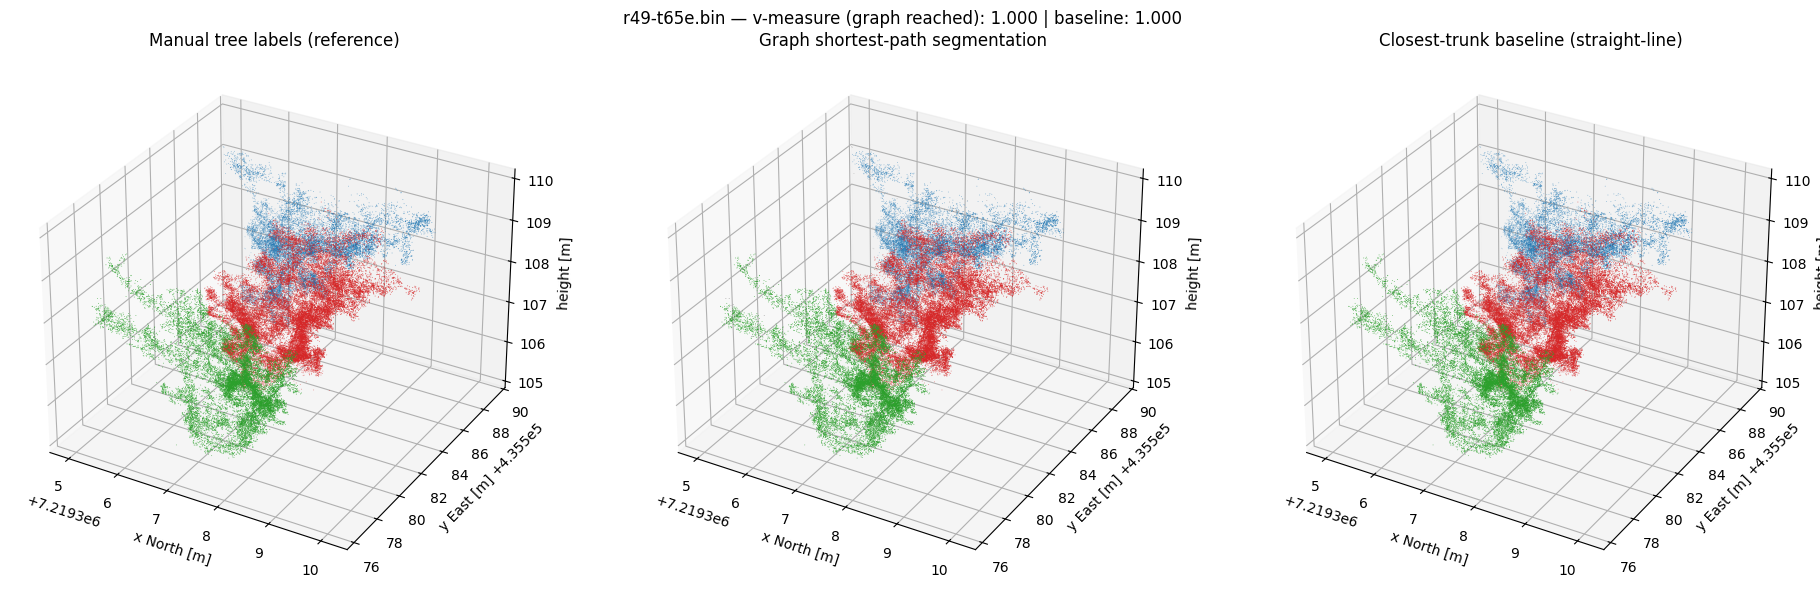

In [ ]:
sel = rng.choice(np.where(m123)[0], size=min(70_000, int(m123.sum())), replace=False)
PRED_COLORS = {1: "#d62728", 2: "#1f77b4", 3: "#2ca02c", -1: "#7f7f7f"}
panels = [
    (tree[sel], TREE_COLORS, "Manual tree labels (reference)"),
    (point_pred[sel], PRED_COLORS, "Graph shortest-path segmentation"),
    (baseline_point[sel], PRED_COLORS, "Closest-trunk baseline (straight-line)"),
]
fig = plt.figure(figsize=(19, 6))
for k, (labels, cmap, title) in enumerate(panels):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    order = np.argsort(labels)
    ax.scatter(x[sel][order], y[sel][order], h_up[sel][order],
               c=[cmap[int(l)] for l in labels[order]], s=0.4, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel("x North [m]"); ax.set_ylabel("y East [m]"); ax.set_zlabel("height [m]")
fig.suptitle(f"r49-t65e.bin — v-measure (graph reached): "
             f"{v_measure_score(tree[reached_mask], point_pred[reached_mask]):.3f} | "
             f"baseline: {v_measure_score(tree[m123], baseline_point[m123]):.3f}")
plt.tight_layout()
plt.show()

## Interpretation, limitations and validation record

**Reading the result.** The results table scores the graph shortest-path segmentation against the manual tree labels of this stand, with the closest-trunk baseline alongside. In the paper, the graph method's advantage over the baseline appears where canopies and branches **overlap** and straight-line distance misassigns points (§III-B, Fig. 14); how much overlap this particular stand has can be judged from the side-by-side views and the coverage column (the graph method discards points its matter graph cannot connect to a trunk — the paper's Fig. 14 notes these can be recovered by the closest-trunk fallback, which we report as a separate row). The paper's 0.915 is an average over all 40 real clouds — a single cloud may legitimately score higher or lower, and a perfect score on a well-separated stand is consistent with the method.

**Differences from the paper / 論文との違い.**
- AI-assisted Python translation of §II-B/§II-D (Dijkstra instead of A* — identical shortest-path lengths; same $R_g$, $v_s$, $R_e$). The author's Bash/comma-snark implementation was not executed.
- Ground removal is an equivalent grid implementation of the paper's local-minimum rule; the author's exact script is unpublished here, and the 0.2 m tolerance is a documented choice.
- Trunk seeds come from the dataset's manual labels instead of the paper's trunk detection (§II-C, out of scope); unweighted edges (§II-B "simplest form"); enrichment (§II-B1) omitted per §IV-B.
- The dataset's label encoding differs from its record page (ground plane is `matter_label == 2` / `tree_label == 4` in the bytes); the notebook prints the observed cross-tabulation rather than trusting the description.

**Validation record.** Executed end-to-end on a fresh Google Colab **CPU** runtime (see saved outputs for the actual date, package versions and timings); the sample was verified by SHA-256 before parsing. This is a single-example demonstration, **not** a verification of the paper's dataset-level results.

**References.**
1. Westling et al., arXiv:2009.13727v2 — method §§II-B, II-D; results §III-B.
2. GraphTreeLS, commit `dc9ca8c7f6518bd90f41df411335014504b5ca17` (README, config). https://github.com/fwestling/GraphTreeLS
3. Westling, *Avocado tree point clouds with class labels*, Mendeley Data V1, DOI `10.17632/h49fpprg6c.1` (CC BY 4.0).
4. ACFR comma / snark: https://github.com/acfr/comma , https://github.com/acfr/snark